In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error , r2_score

In [9]:
# data = fetch_california_housing(as_frame=True)
# x = data.data
# y = data.target
# print("California Housing data loaded using fetch_california_housing.")

# x.head()

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
# Perform one-hot encoding on the 'ocean_proximity' column
x = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

x = pd.get_dummies(x, columns=["ocean_proximity"], drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [11]:
# Model Declaration
gbr = GradientBoostingRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42   
)
gbr.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [15]:
# in previous run it showed error because it has missing values
# the reason i needed to do these 2 lines before predict
x_train = x_train.dropna()
x_test = x_test.dropna()
pred = gbr.predict(x_test)

In [22]:
# no of row col are not same in x_test and y_test so lets do Best fit
test_data = pd.concat([x_test,y_test],axis=1)
test_data= test_data.dropna()

x_test = test_data.drop(['median_house_value'], axis=1)
y_test = test_data['median_house_value']

mse = mean_squared_error(y_test , pred)
r2 = r2_score(y_test , pred)

print('mse: ',mse)
print('r2: ',r2)

mse:  3100951087.035052
r2:  0.7640264144737683


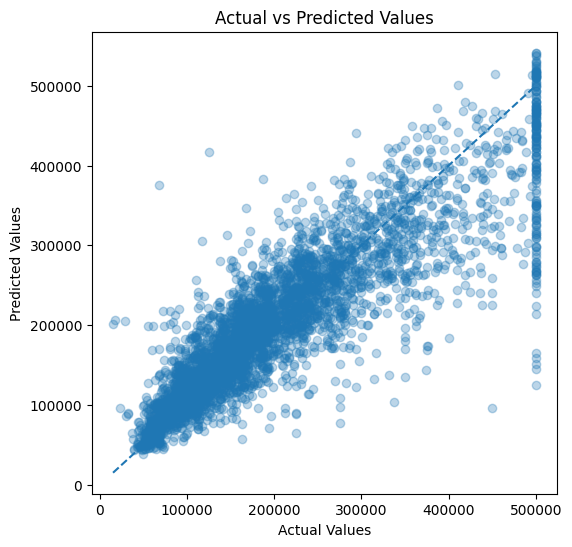

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

# Effect of learning rate

In [27]:
learning_rates = [0.01,0.05,0.1,0.2,0.8]
results=[]

for lr in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    model.fit(x_train , y_train)
    preds = model.predict(x_test)
    results.append((lr , r2_score(y_test,preds)))

pd.DataFrame(results , columns = ['Learning Rate' , 'R2_score'])

,Learning Rate,R2_score
0,0.01,0.508206
1,0.05,0.707243
2,0.10,0.764026
3,0.20,0.791946
4,0.80,0.795631


# Effect of Tree Depth


In [29]:
depth = [1,2,3,4,7]
results=[]

for depth in depth:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    model.fit(x_train , y_train)
    preds = model.predict(x_test)
    results.append((depth , r2_score(y_test,preds)))

pd.DataFrame(results , columns = ['Max depth' , 'R2_score'])

,Max depth,R2_score
0,1,0.615678
1,2,0.714610
2,3,0.764026
3,4,0.794628
4,7,0.826270


In [31]:
feature_importance = gbr.feature_importances_

importance_df = pd.Series(
    feature_importance, index=x.columns
).sort_values(ascending=False)

importance_df.head(10)

median_income                 0.588018
ocean_proximity_INLAND        0.168416
longitude                     0.086303
latitude                      0.048448
housing_median_age            0.041398
population                    0.025039
total_bedrooms                0.021696
ocean_proximity_NEAR OCEAN    0.006269
households                    0.006032
ocean_proximity_NEAR BAY      0.005186
dtype: float64